# 01 — Exploratory Data Analysis
Understand the raw Spotify dataset before any preprocessing.

**Update `DATA_PATH` below to point to your CSV file.**

In [ ]:
DATA_PATH = 'data/raw/dataset.csv'  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 120,
})

## 1. Load & basic inspection

In [3]:
df = pd.read_csv(DATA_PATH)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print('Shape:', df.shape)
df.head(3)

Shape: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


In [4]:
print('Dtypes:')
print(df.dtypes)
print('\nNull counts (non-zero only):')
nulls = df.isnull().sum()
print(nulls[nulls > 0])
print('\nDuplicate track_ids:', df['track_id'].duplicated().sum())
print('Unique genres:      ', df['track_genre'].nunique())

Dtypes:
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

Null counts (non-zero only):
artists       1
album_name    1
track_name    1
dtype: int64

Duplicate track_ids: 24259
Unique genres:       114


## 2. Target distribution (popularity)

In [5]:
print(df['popularity'].describe())
print(f"\nZero-popularity tracks: {(df['popularity'] == 0).sum():,} "
      f"({(df['popularity'] == 0).mean()*100:.1f}%)")

count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

Zero-popularity tracks: 16,020 (14.1%)


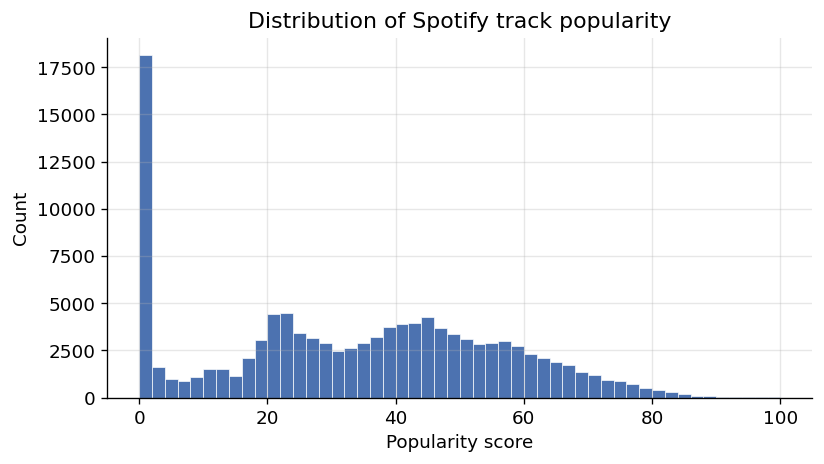

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['popularity'], bins=50, color='#4C72B0', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Popularity score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Spotify track popularity')
fig.tight_layout()
fig.savefig('figures/01_popularity_distribution.png')
plt.show()

## 3. Audio feature distributions

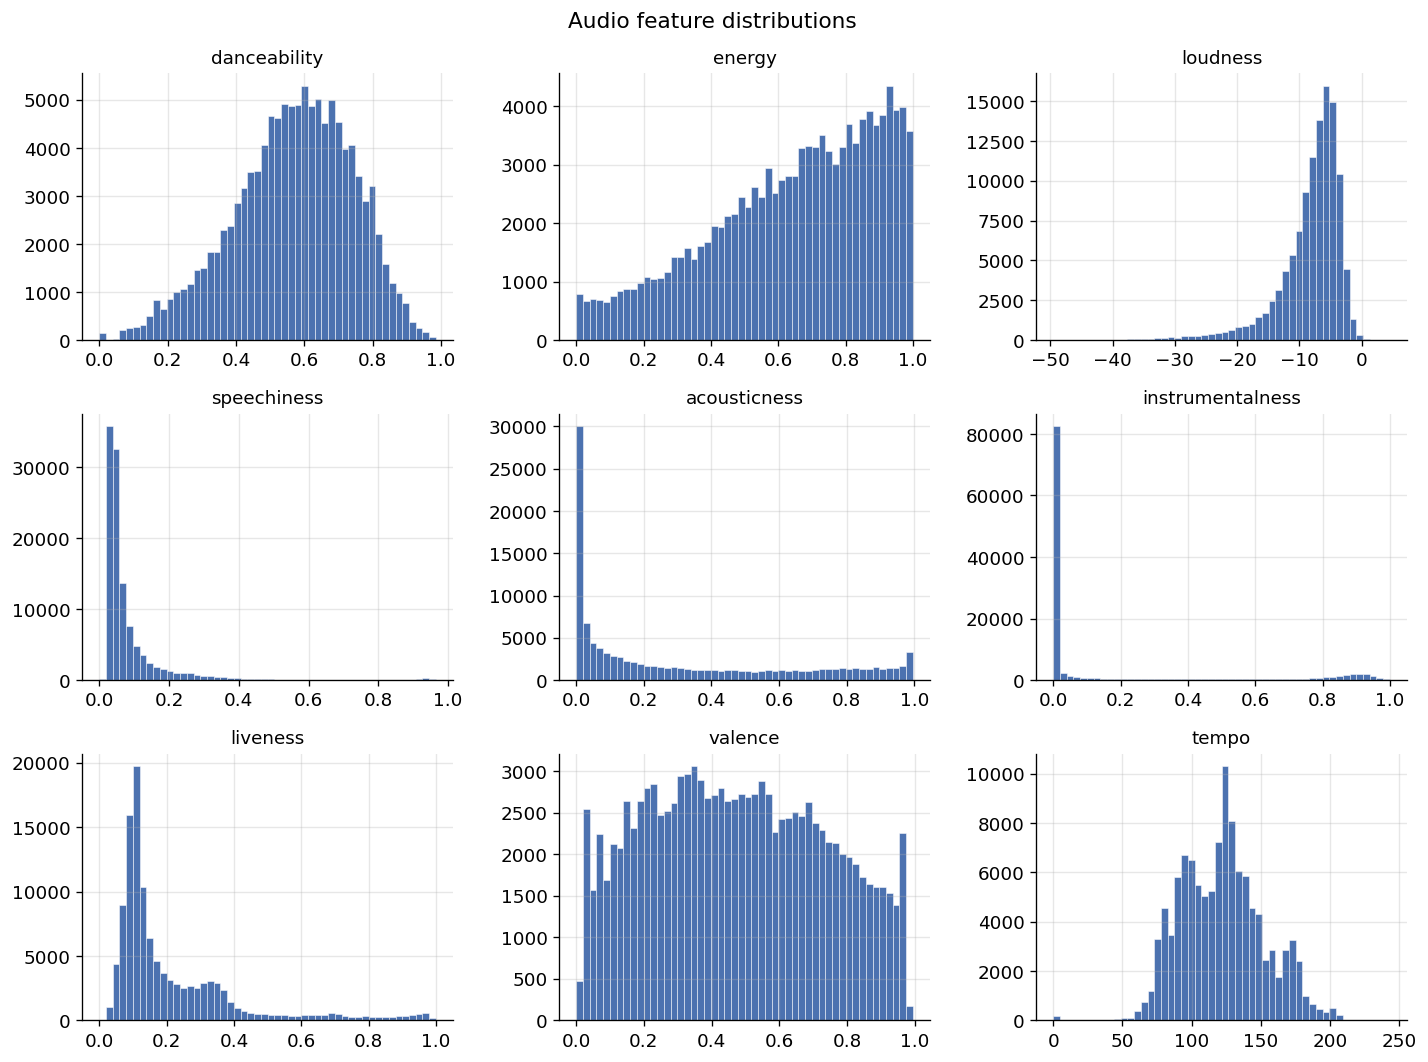

In [7]:
audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, feat in zip(axes.flat, audio_features):
    ax.hist(df[feat].dropna(), bins=50, color='#4C72B0', edgecolor='white', linewidth=0.3)
    ax.set_title(feat, fontsize=11)
plt.suptitle('Audio feature distributions', fontsize=13)
plt.tight_layout()
fig.savefig('figures/02_audio_distributions.png')
plt.show()

## 4. Correlation heatmap

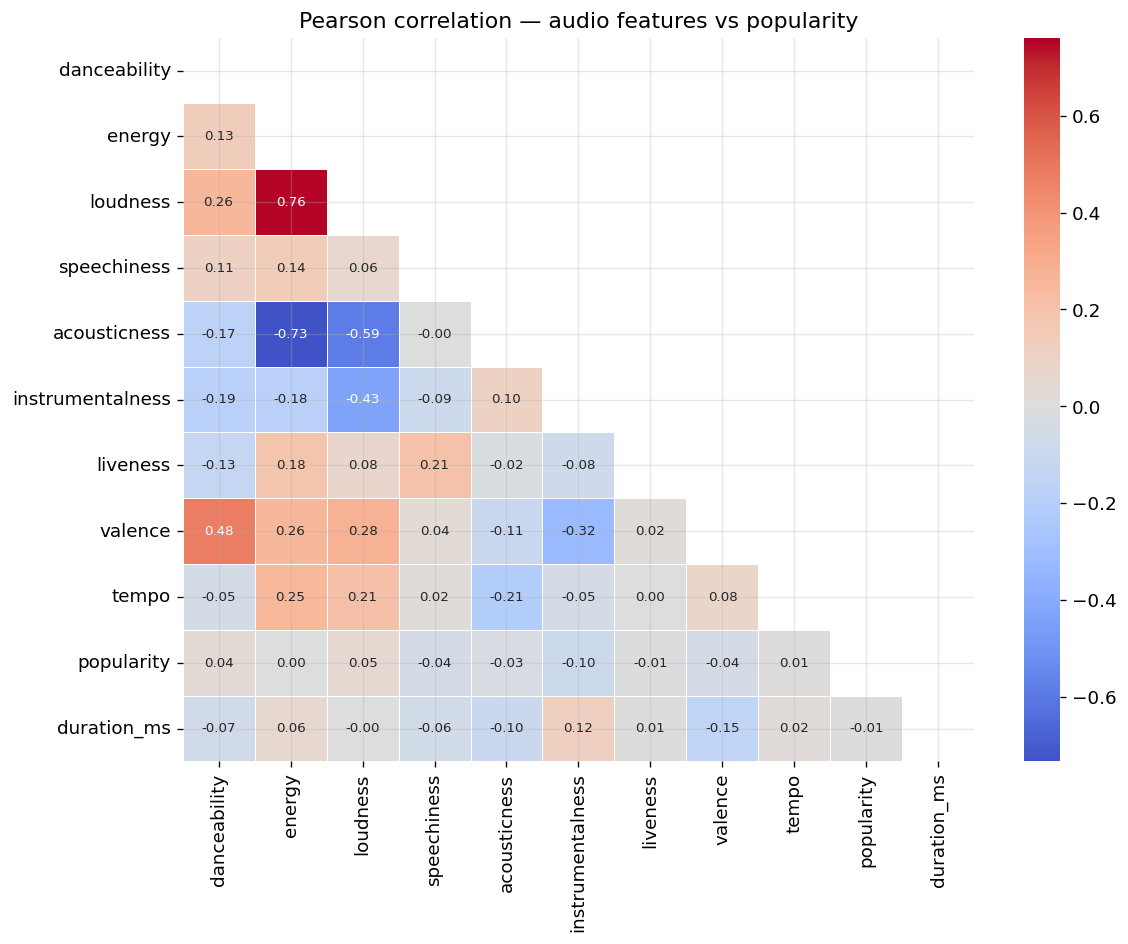

In [8]:
num_cols = audio_features + ['popularity', 'duration_ms']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.4, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Pearson correlation — audio features vs popularity')
fig.tight_layout()
fig.savefig('figures/03_correlation_heatmap.png')
plt.show()

## 5. Popularity by genre (top & bottom 20)

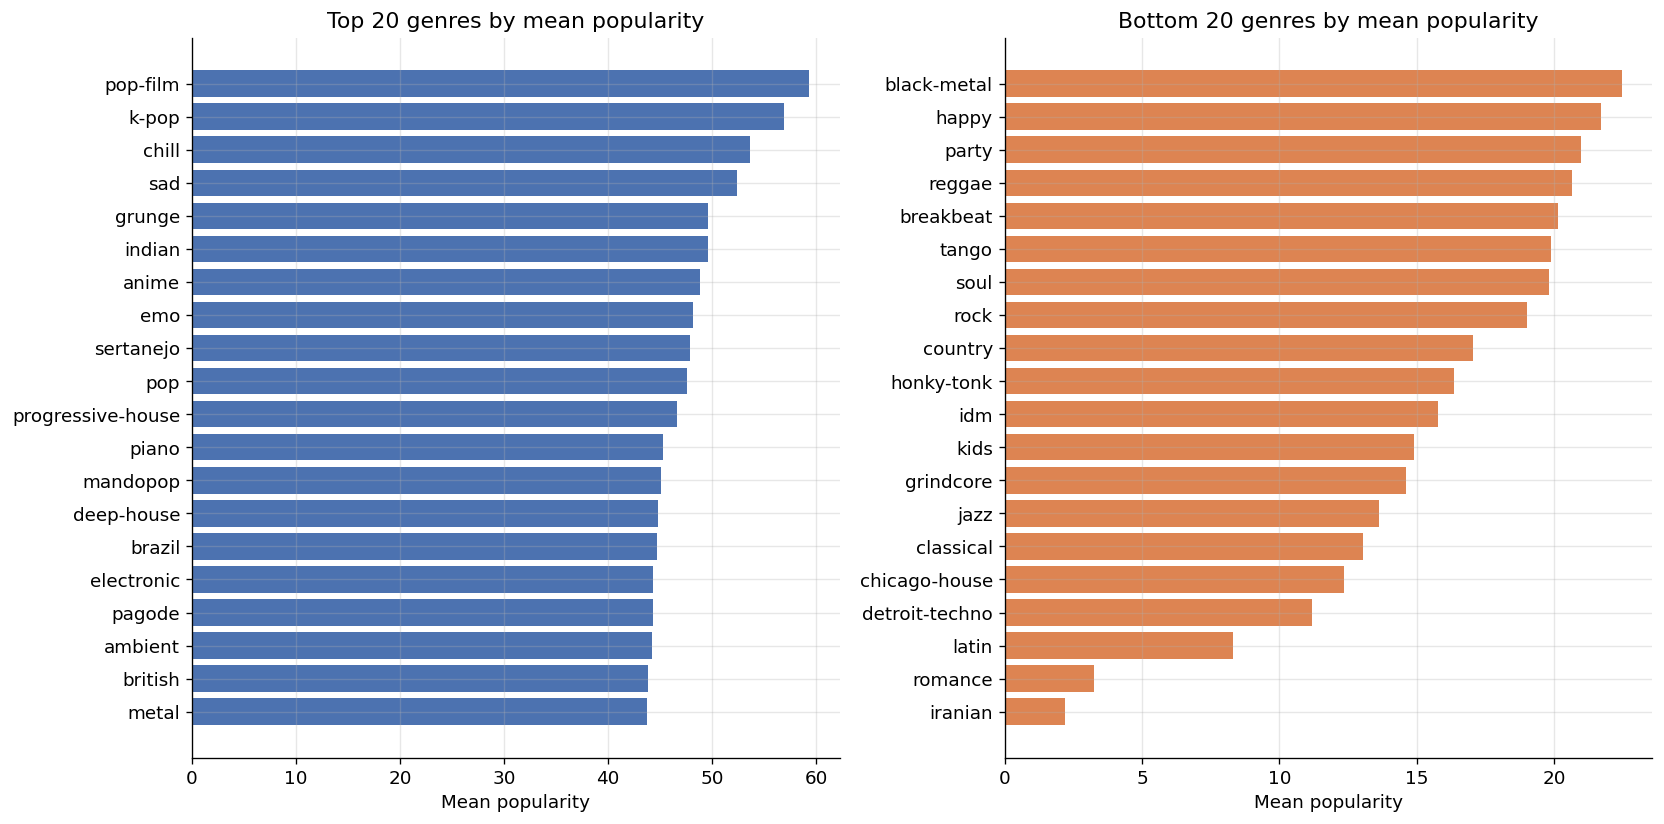

In [9]:
genre_means = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
top20  = genre_means.head(20)
bot20  = genre_means.tail(20).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, data, color, title in zip(
    axes,
    [top20[::-1], bot20],
    ['#4C72B0', '#DD8452'],
    ['Top 20 genres by mean popularity', 'Bottom 20 genres by mean popularity']
):
    ax.barh(data.index, data.values, color=color)
    ax.set_xlabel('Mean popularity')
    ax.set_title(title)
fig.tight_layout()
fig.savefig('figures/04_genre_popularity.png')
plt.show()

## 6. PCA projection of audio features (coloured by popularity)

Variance explained — PC1: 31.4%, PC2: 16.5%


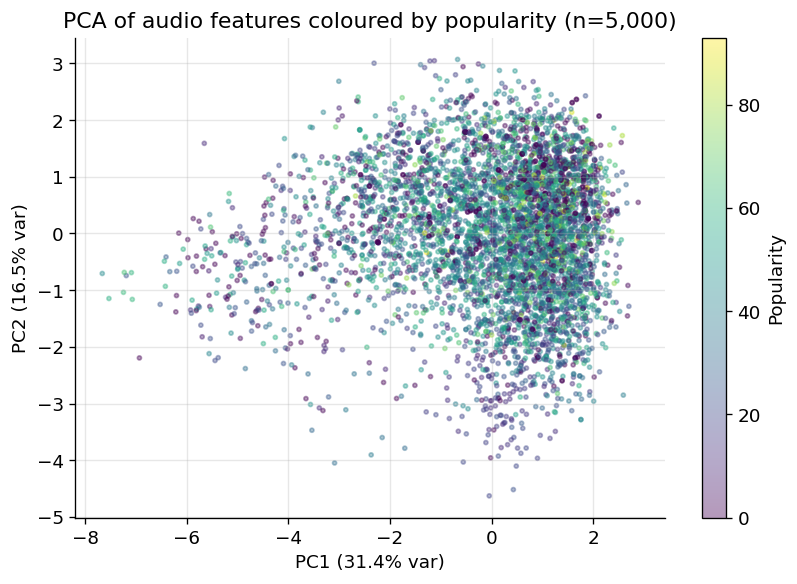

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Use a random sample so the plot stays readable
sample = df[audio_features + ['popularity']].dropna().sample(5000, random_state=42)

X_scaled = StandardScaler().fit_transform(sample[audio_features])
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)

print(f'Variance explained — PC1: {pca.explained_variance_ratio_[0]:.1%}, '
      f'PC2: {pca.explained_variance_ratio_[1]:.1%}')

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    components[:, 0], components[:, 1],
    c=sample['popularity'].values, cmap='viridis',
    alpha=0.4, s=6, rasterized=True
)
plt.colorbar(sc, ax=ax, label='Popularity')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('PCA of audio features coloured by popularity (n=5,000)')
fig.tight_layout()
fig.savefig('figures/05_pca_projection.png')
plt.show()